In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import scintools 
# import psrsigsim as pss
from scintools.scint_sim import Simulation
import scintools.ththmod as THTH
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.signal import peak_widths
from scipy.interpolate import griddata
from mwprop.nemod.NE2025 import ne2025

from src import dmbeat
from src.psrsigsim.signal.fb_signal import FilterBankSignal
from src.psrsigsim.pulsar.profiles import GaussProfile
from src.psrsigsim.pulsar.pulsar import Pulsar
from src.psrsigsim.ism.ism import ISM
from src.rm_sim import rm_sim
from src.scint_sim import calc_params, scint_sim 

import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [10]:
sim = Simulation()

In [11]:
pulsar = 'J0630-2834'
DM = 34.425
f_start = 150 # freq lower bound in MHz
f_stop = 151 # freq upper bound in MHz
veff = 77.3 # effective transverse velocity in km/s
dt = 10 # integration time in seconds
nmin = 60 # overall obs time in min


RA = f'{pulsar[1:3]} {pulsar[3:5]} 00'
DEC = f'{pulsar[5:8]} {pulsar[8:10]} 00'
print(RA, DEC)

lf = f_start
rf = f_stop
cf = (lf+rf)/2
bw = rf-lf
frac_bw = bw/cf

06 30 00 -28 34 00


In [12]:
mb2, rfresnel_m, screendist_m = calc_params(RA=RA, DEC=DEC, DM=DM, cf=cf, veff=veff)

#NE2025 input: 4 parameters
   236.8691         l             (deg)                    GalacticLongitude                  
   -16.9209         b             (deg)                    GalacticLatitude                   
    34.4250         DM/D          (pc cm^{-3}_or_kpc)      Input DM or Distance               
          1         ndir          1:DM->D;-1:D->DM         Which?(DM or D)                    
#NE2025 output: 17 values
     0.4479         DIST          (kpc)                    ModelDistance                      
    34.4250         DM            (pc cm^{-3})             DispersionMeasure                  
    10.0194         DMz           (pc cm^{-3})             DM_Zcomponent                      
 7.2925e-05         SM            (kpc m^{-20/3})          ScatteringMeasure                  
 1.0165e-04         SMtau         (kpc m^{-20/3})          SM_PulseBroadening                 
 8.5411e-05         SMtheta       (kpc m^{-20/3})          SM_GalAngularBroadening         

ds 0.0006009809204456757
ns 6656
ds 0.0006009809204456757 ns 6656 time 32.28521203994751


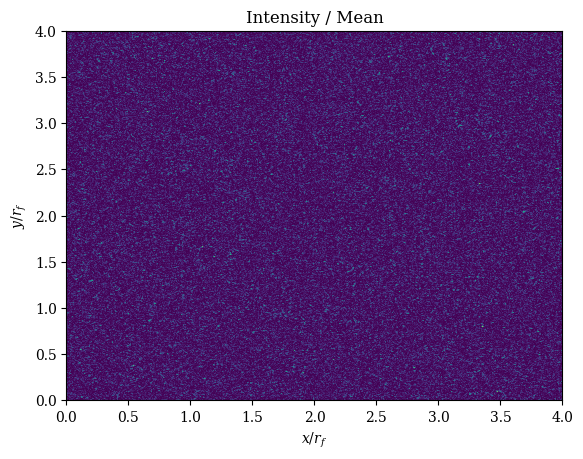

In [13]:
dspec, tlim = scint_sim(mb2, rfresnel_m, screendist_m, veff=veff, f_start=f_start, f_stop=f_stop, dt=dt, nmin=nmin, seed=3)

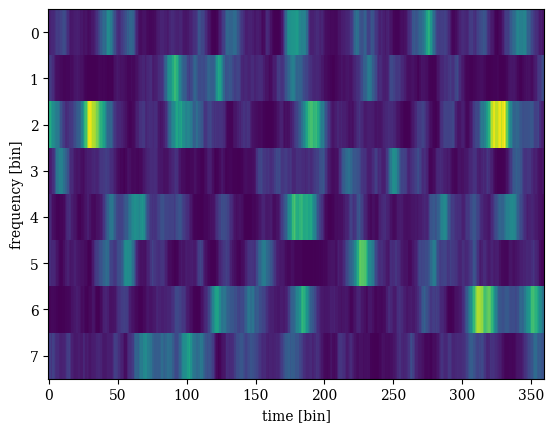

In [18]:
plt.imshow(dspec, aspect='auto', interpolation='none')
plt.ylabel('frequency [bin]')
plt.xlabel('time [bin]')
plt.show()

In [16]:
np.savez('/Users/user/Downloads/dspec.npz', dspec=dspec, tlim=tlim)